# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [12]:
weight = 3
bias = -10

### Logistic Regression Predictions

In [13]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

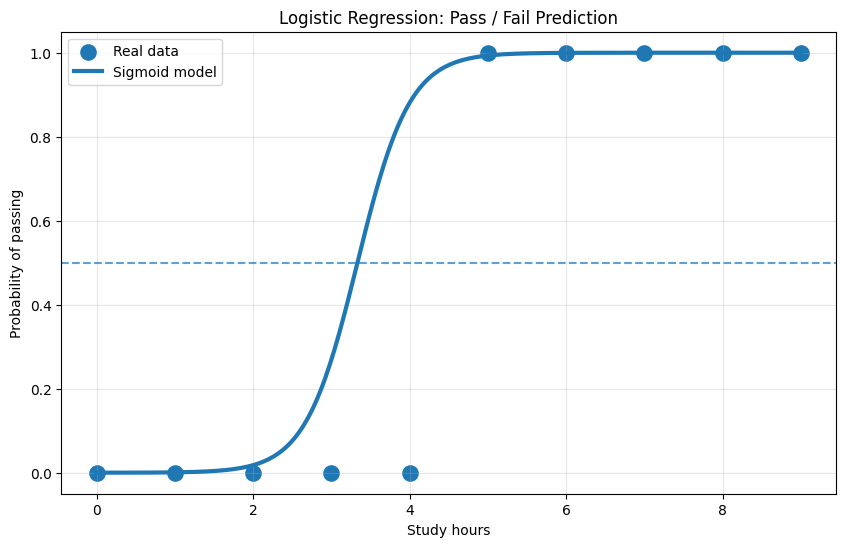

In [14]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions
1. What does the weight control?  
- It controls the steepness of the sigmoid curve - higher means sharper, easy to clasify between the trnasition of 0 and 1.

2. What does the bias control?
- The bias shift the residual line to the left and right alont the x-axis.

3. What happens when the sigmoid becomes steeper?
- The sigmoid model can clearly seprate 2 classes, probabilites stay near 0 and 1. 

4. Where is the decision boundary?
- Between 4 and 5 hours
For this situation, weight x x + bias = 0 --> x = -bias/weight = -(-7)/1.5 = 4.67 hours

5. Which students are difficult to classify?
- The student that have the study hours nearly the boundary (4 hours - fail and 5 hours - pass). Which means small change in bias or weight can change the prediction. 

6. Why is logistic regression better than linear regression here?
- Because there are only 2 outputs: 0 or 1 (fail or pass), not predicting their marks

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [15]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
# x = fare, y = survived
x = df["Fare"].values
y = df["Survived"].values

x = np.array(x)
y = np.array(y)

In [17]:
#x = x[:30]
#y = y[:30]

w = 0.004
b = -0.5
z = w * x + b

p = 1 / (1 + np.exp(-z))

y_pred = (p > 0.5).astype(int)

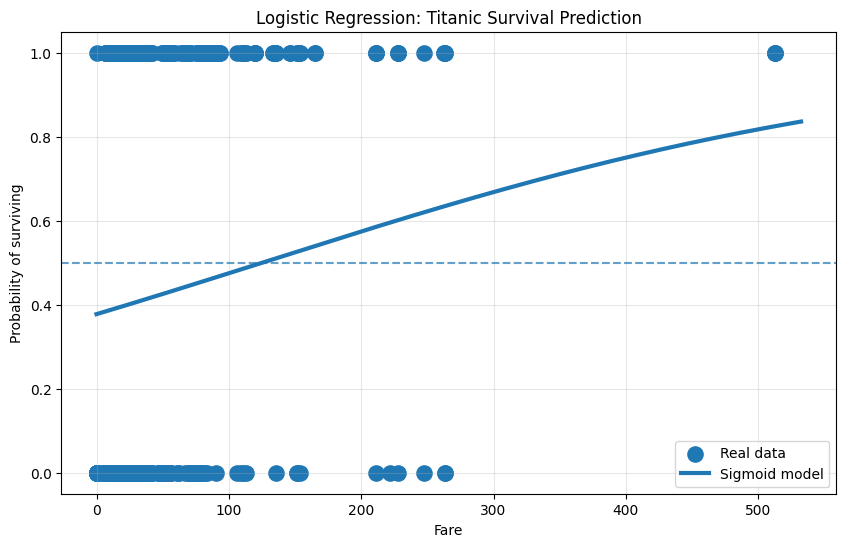

In [18]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, max(x)+20, 300)
z_curve = w * x_curve + b
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Fare")
plt.ylabel("Probability of surviving")
plt.title("Logistic Regression: Titanic Survival Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [19]:
mask = ~np.isnan(x)

x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

model = LogisticRegression()
model.fit(x_clean, y_clean)

print("Weight:", model.coef_[0][0])
print("Bias:  ", model.intercept_[0])
print("Accuracy:", model.score(x_clean, y_clean))

Weight: 0.015196166636023509
Bias:   -0.9412922219929756
Accuracy: 0.6655443322109988


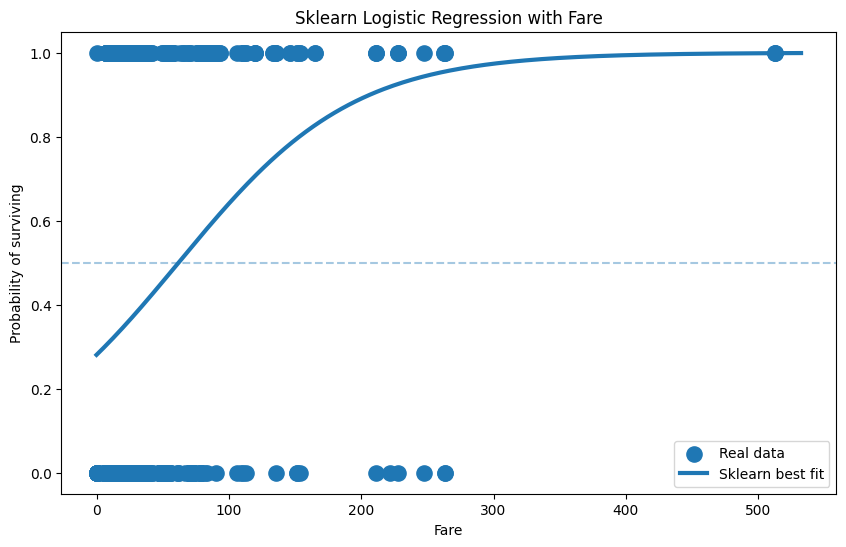

In [20]:
x_curve = np.linspace(0, max(x_clean)+20, 300)

z_sklearn = model.coef_[0][0] * x_curve + model.intercept_[0]
p_sklearn = 1 / (1 + np.exp(-z_sklearn))

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=120, label="Real data")
plt.plot(x_curve, p_sklearn, linewidth=3, label="Sklearn best fit")
plt.axhline(0.5, linestyle="--", alpha=0.4)
plt.xlabel("Fare")
plt.ylabel("Probability of surviving")
plt.title("Sklearn Logistic Regression with Fare")

plt.legend()
plt.show()

**Comparision:**  
- My manual model: the sigmoid curve is almost flat --> this is underfitted. It transitions too slowly, making it poor at distinguishing between survival and non-survival based on the fare.    
- Sklearn model: it's much steeper --> it is optimized to find the best possible weights. This results in a curve that accurately captures the rapid jump in survival probability for passengers who paid a higher fare.